Обучающая последовательность (60%):
y: [0.904, 0.922, 0.763, 0.923, 0.918, 0.906, 0.905, 0.545, 0.894, 0.9, 0.932, 0.74]
x_1: [75.5, 78.5, 78.4, 77.7, 84.4, 75.9, 76, 67.5, 78.2, 78.1, 78.6, 84]
x_2: [25.2, 21.8, 25.7, 17.8, 15.9, 22.4, 20.6, 25.2, 20.7, 17.5, 19.7, 18.5]
x_3: [3343, 3001, 3101, 3543, 3237, 3330, 3808, 2415, 3295, 3504, 30565, 3007]
x_4: [77, 78.2, 68, 77.2, 77.2, 77.2, 75.7, 62.6, 78, 78.2, 79, 67.6]

Проверочная последовательность (40%):
y: [0.701, 0.744, 0.921, 0.927, 0.802, 0.747, 0.927, 0.721]
x_1: [59.2, 90.2, 72.8, 67.7, 82.6, 74.4, 83.3, 83.7]
x_2: [54.4, 23, 20.2, 25.2, 22.4, 22.7, 18.1, 20.1]
x_3: [2844, 2861, 3259, 3350, 3344, 2704, 3642, 2753]
x_4: [69.8, 68.4, 77.9, 78.1, 72.5, 66.6, 76.7, 68.8]
Перебор...

--- Проверка пары: x_1 и x_2 ---
Определитель системы: 156166.3404
Коэффициенты: a0=0.3769, a1=0.0086, a2=-0.0091
	MSE на проверочной выборке: 0.0292
	Новая лучшая модель!

--- Проверка пары: x_1 и x_3 ---
Определитель системы: 1652113269335.4045
Коэффи

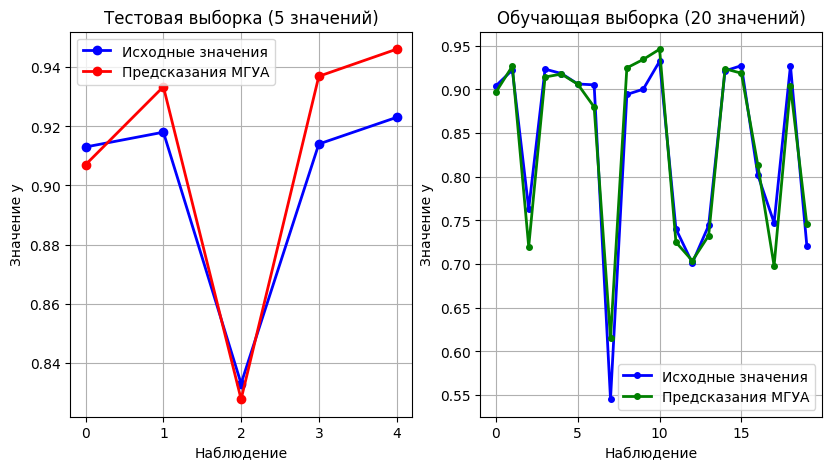

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# Исходные данные
y = [0.904, 0.922, 0.763, 0.923,0.918, 0.906,0.905, 0.545,0.894, 0.9,0.932,
     0.74,0.701, 0.744,0.921, 0.927,0.802, 0.747,0.927, 0.721,
     0.913, 0.918, 0.833, 0.914, 0.923]
x_1 = [75.5,78.5,78.4,77.7,84.4,75.9,76,67.5,78.2,78.1,78.6,84,59.2,
       90.2,72.8,67.7,82.6,74.4,83.3,83.7,73.8,79.2,71.5, 75.3, 79]
x_2 = [25.2,21.8,25.7,17.8,15.9,22.4,20.6,25.2,20.7,17.5,19.7,18.5,
       54.4,23,20.2,25.2,22.4,22.7,18.1,20.1,17.3,16.8,29.9,20.3,14.1]
x_3 = [3343,3001,3101,3543,3237,3330,3808,2415,3295,3504,30565,3007,2844,
       2861,3259,3350,3344,2704,3642,2753,2916,3551,3177,3280,3160]
x_4 = [77,78.2,68,77.2,77.2,77.2,75.7,62.6,78,78.2,79,67.6,69.8,68.4,
       77.9,78.1,72.5,66.6,76.7,68.8,76.8,78.1,73.9,78.6,78.5]
data = [y, x_1, x_2, x_3, x_4]

def dual_regres(list_1, list_2, list_3):
    """Функция для построения парной регрессии y = a0 + a1*xi + a2*xj"""
    local_data = []
    local_data.append(list_1)  # y
    local_data.append(list_2)  # xi
    local_data.append(list_3)  # xj

    len_numb_seq = len(local_data[0])

    # Основные суммы
    sum_list_1 = sum(local_data[0])
    sum_list_2 = sum(local_data[1])
    sum_list_3 = sum(local_data[2])

    # Квадраты значений
    squart_numb_2 = [round(numb*numb, 4) for numb in local_data[1]]  # xi^2
    squart_numb_3 = [round(numb*numb, 4) for numb in local_data[2]]  # xj^2

    sum_list_2_sq = sum(squart_numb_2)
    sum_list_3_sq = sum(squart_numb_3)

    # Произведения
    mult_1_2_numb = [round(local_data[0][i]*local_data[1][i], 4) for i in range(len_numb_seq)]  # y*xi
    mult_1_3_numb = [round(local_data[0][i]*local_data[2][i], 4) for i in range(len_numb_seq)]  # y*xj
    mult_2_3_numb = [round(local_data[1][i]*local_data[2][i], 4) for i in range(len_numb_seq)]  # xi*xj

    sum_mult_1_2 = sum(mult_1_2_numb)
    sum_mult_1_3 = sum(mult_1_3_numb)
    sum_mult_2_3 = sum(mult_2_3_numb)

    '''
    Матрица системы уравнений для метода наименьших квадратов
    n*a0 + sum(xi)*a1 + sum(xj)*a2 = sum(y)
    sum(xi)*a0 + sum(xi^2)*a1 + sum(xi*xj)*a2 = sum(y*xi)
    sum(xj)*a0 + sum(xi*xj)*a1 + sum(xj^2)*a2 = sum(y*xj)
    '''
    A = np.array([
        [len_numb_seq, sum_list_2, sum_list_3],
        [sum_list_2, sum_list_2_sq, sum_mult_2_3],
        [sum_list_3, sum_mult_2_3, sum_list_3_sq]
    ])

    B = np.array([sum_list_1, sum_mult_1_2, sum_mult_1_3])

    # Вычисление определителей методом Крамера
    det_A = np.linalg.det(A)

    # Матрица для a0
    A0 = A.copy()
    A0[:, 0] = B
    det_A0 = np.linalg.det(A0)

    # Матрица для a1
    A1 = A.copy()
    A1[:, 1] = B
    det_A1 = np.linalg.det(A1)

    # Матрица для a2
    A2 = A.copy()
    A2[:, 2] = B
    det_A2 = np.linalg.det(A2)

    # Коэффициенты регрессии
    a0 = det_A0 / det_A
    a1 = det_A1 / det_A
    a2 = det_A2 / det_A

    print(f"Определитель системы: {round(det_A,4)}")
    print(f"Коэффициенты: a0={round(a0, 4)}, a1={round(a1, 4)}, a2={round(a2, 4)}")

    return a0, a1, a2, det_A

'''
В качестве обучающей выборки взять первые 20
значений паттерна, в качестве тестовой выборки, оставшиеся 5 паттернов
исходной таблицы. Обучающую выборку поделить на две в соотношении: 60%
и 40% (непосредственно обучающая выборка и проверочная выборка для
отбора по МГУА)
'''

res_numb_learn = []
res_numb_test = []
for numb_list in data:
    res_numb_learn.append(numb_list[:20])
    res_numb_test.append(numb_list[20:])

learn_subseq = []
chech_subseq = []
for learn_numb in res_numb_learn:
    len_list = int(len(learn_numb) * 0.6)
    learn_subseq.append(learn_numb[:len_list])  # 60% для обучения
    chech_subseq.append(learn_numb[len_list:])  # 40% для проверки

print("Обучающая последовательность (60%):")
print(f"y: {learn_subseq[0]}")
print(f"x_1: {learn_subseq[1]}")
print(f"x_2: {learn_subseq[2]}")
print(f"x_3: {learn_subseq[3]}")
print(f"x_4: {learn_subseq[4]}")

print("\nПроверочная последовательность (40%):")
print(f"y: {chech_subseq[0]}")
print(f"x_1: {chech_subseq[1]}")
print(f"x_2: {chech_subseq[2]}")
print(f"x_3: {chech_subseq[3]}")
print(f"x_4: {chech_subseq[4]}")

# Перебор всех возможных пар переменных для МГУА
best_model = None
best_error = float(1)
best_vars = None

variables = ['x_1', 'x_2', 'x_3', 'x_4']
variable_indices = {'x_1': 1, 'x_2': 2, 'x_3': 3, 'x_4': 4}
all_variables = list(combinations(variables, 2))

print("Перебор...")

for pair in all_variables:
    var1 = pair[0]
    var2 = pair[1]

    print(f"\n--- Проверка пары: {var1} и {var2} ---")

    # Построение модели на обучающей части
    idx1 = variable_indices[var1]
    idx2 = variable_indices[var2]

    a0, a1, a2, det = dual_regres(
        learn_subseq[0],  # y
        learn_subseq[idx1],  # xi
        learn_subseq[idx2]   # xj
    )

        # Проверка модели на проверочной выборке
    val_y = chech_subseq[0]
    val_x1 = chech_subseq[idx1]
    val_x2 = chech_subseq[idx2]

        # Расчет предсказанных значений
    predicted = []
    for k in range(len(val_y)):
        y_pred = a0 + a1 * val_x1[k] + a2 * val_x2[k]
        predicted.append(y_pred)

        # Расчет среднеквадратичной ошибки
    mse = 0
    for k in range(len(val_y)):
        mse += (predicted[k] - val_y[k]) ** 2
    mse = mse / len(val_y)

    print(f"\tMSE на проверочной выборке: {round(mse, 4)}")

    if mse < best_error:
        best_error = mse
        best_model = (a0, a1, a2)
        best_vars = (var1, var2)
        print("\tНовая лучшая модель!")

print(f"\tЛучшая модель: {best_vars[0]} и {best_vars[1]}")
print(f"\t\tКоэффициенты: a0={round(best_model[0], 4)}, a1={round(best_model[1], 4)}, a2={round(best_model[2], 4)}")
print(f"\t\t\tЛучшая MSE: {round(best_error, 4)}")

# Обучение лучшей модели на всей обучающей выборке (20 значений)
print(f"\nОбучение финальной модели на всей обучающей выборке...")
idx1_final = variable_indices[best_vars[0]]
idx2_final = variable_indices[best_vars[1]]

a0_final, a1_final, a2_final, det_final = dual_regres(
    res_numb_learn[0],  # y (все 20 значений)
    res_numb_learn[idx1_final],  # xi (все 20 значений)
    res_numb_learn[idx2_final]   # xj (все 20 значений)
)

print(f"\tФинальная модель: y = {a0_final:.6f} + {a1_final:.6f}*{best_vars[0]} + {a2_final:.6f}*{best_vars[1]}")

# Тестирование на тестовой выборке (последние 5 значений)
test_y = res_numb_test[0]
test_x1 = res_numb_test[idx1_final]
test_x2 = res_numb_test[idx2_final]

# Предсказания для тестовой выборки
test_predicted = []
for k in range(len(test_y)):
    y_pred = a0_final + a1_final * test_x1[k] + a2_final * test_x2[k]
    test_predicted.append(y_pred)

# Расчет ошибок аппроксимации
errors = []
for k in range(len(test_y)):
    error = abs((test_predicted[k] - test_y[k]) / test_y[k]) * 100
    errors.append(error)

mean_error = sum(errors) / len(errors)

# Построение графиков
plt.figure(figsize=(15, 5))

# График 1: Тестовая выборка
plt.subplot(1, 3, 1)
plt.plot(range(len(test_y)), test_y, 'bo-', label='Исходные значения', linewidth=2, markersize=6)
plt.plot(range(len(test_predicted)), test_predicted, 'ro-', label='Предсказания МГУА', linewidth=2, markersize=6)
plt.xlabel('Наблюдение')
plt.ylabel('Значение y')
plt.title('Тестовая выборка (5 значений)')
plt.legend()
plt.grid(True)

# График 2: Вся обучающая выборка
train_predicted = []
for k in range(len(res_numb_learn[0])):
    y_pred = a0_final + a1_final * res_numb_learn[idx1_final][k] + a2_final * res_numb_learn[idx2_final][k]
    train_predicted.append(y_pred)

plt.subplot(1, 3, 2)
plt.plot(range(len(res_numb_learn[0])), res_numb_learn[0], 'bo-', label='Исходные значения', linewidth=2, markersize=4)
plt.plot(range(len(train_predicted)), train_predicted, 'go-', label='Предсказания МГУА', linewidth=2, markersize=4)
plt.xlabel('Наблюдение')
plt.ylabel('Значение y')
plt.title('Обучающая выборка (20 значений)')
plt.legend()
plt.grid(True)

print(f"Средняя ошибка аппроксимации составляет {round(mean_error, 2)}%")